Open this notebook in Jupyter or upload it to Colab to run it.

# Linear Regression with Gradient Descent

## Overview:
This notebook builds a univariate linear regression model for food-truck profits and fits its intercept and slope with gradient descent.

Download the data that you will use by running this command, and read it in using:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv("../data/food_truck_profits.csv", header=None, names=['X', 'Y'])

--2023-03-10 20:04:01--  https://raw.githubusercontent.com/porterjenkins/cs180-intro-data-science/master/data/food-truck.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1359 (1.3K) [text/plain]
Saving to: ‘food-truck.csv.16’

food-truck.csv.16   100%[===================>]   1.33K  --.-KB/s    in 0s      

2023-03-10 20:04:02 (63.6 MB/s) - ‘food-truck.csv.16’ saved [1359/1359]



We will restrict ourselves to a linear hypothesis space, constructing a model that adheres to the following form:
$$ f _\Theta(x) = \theta _0 + \theta _1x $$

You might notice that this equation is similar to the linear equation: $$ f(x) = b + mx $$

(Yes you did use y=mx+b after 8th grade 😜)


The model learns two parameters: $\theta_0$, the intercept, and $\theta_1$, the slope. This is a least-squares linear regression model.

Given data, your goal will be to estimate the parameters of this model using the method of steepest gradient descent. The parameters are defined within the construct:
$$ \theta_p = \{\theta_0,\theta_1\} $$

which is the vector of learnable coefficients. The intercept is $\theta_0$ and the slope is $\theta_1$. We can learn these parameters by minimizing average squared error. Thus, the loss function you will want to implement is:

Equation 1: $$ L(\Theta) = \frac{1}{2m}\sum_{i=1}^m (f(x^i)-y^i)^2 $$

$$L(\Theta) = \frac{1}{2m}\sum_{i=1}^m (\theta_0 + \theta_1x_i-y_i)^2$$

This equation may look very scary at first, but it's really not that scary, so let's break it down, and define our variables.
*   m is the number of datapoints in the data set.
*   i is the index of the data point tuple that we're looking at in the sum.
*   L is the loss function (think of it like f(x)).
*   $\Theta$ is the list of parameters to estimate.
*   $(f(x^i)-y^i)^2$ is the squared difference between the predicted output and the actual output.

So wrapping it all together, the loss function is taking the sum of the squared differences, and dividing it by double the number of datapoints in the dataset.

The goal of this exercise is to minimize the loss function, which brings predictions closer to the observed values on average.



## Exercise 1: The Dark Descent (Compute Loss)

In order to correctly recreate the gradient descent algorithm, you need to compute the loss function. Use the equation for loss given in the introduction to fill out the functions below to correctly produce the right loss.

In [2]:
def predict(X, theta):
    # TODO: Write the code to output the predicted y values based on the X values
    # Hint: Remember that theta is a tuple consisting of theta_0 and theta_1
    y_predictions = theta[0] + (theta[1] * X)
    return y_predictions

In [3]:
def sum_mean_squared_error(y, y_hat):
    # TODO: Write the sum of the mean squared error
    # Hint: Follow the loss equation
#     difference = y_hat - y
#     squared_difference = difference * difference
#     summed = squared_difference.sum()
    mean_squared_error = (1 / (2 * len(y))) * np.sum((y_hat - y) **2)
    return mean_squared_error

In [4]:
def calculate_loss(X, y, theta):
    # TODO: Write your compute loss function below
    # Hint: You'll use the predict and the sum_mean_squared_error functions defined above
    y_hat = predict(X, theta)
    loss = sum_mean_squared_error(y, y_hat)
    return loss

Explain to me like I'm five what the code above is doing:

> The first function, `predict`, takes in a bunch of number-pairs (but you only have 1 of two numbers in each pair), and estimates what the second value each of those pairs have by plugging it into an estimating function.

> The second function, `sum_mean_squared_error`, tells you how good or bad each predictions from the `predict` function are. Smaller numbers are better.

> The thrid function, `calculate_loss`, puts everything together into one number. All of the individual good/bad values from the previous function (`sum_mean_squared_error`) become one value, where smaller is better.

## Exercise 2: Partial Derivatives

Analytically derive the gradient of the loss function with respect to the model parameters, $\theta_0$ and $\theta_1$. (take the partial derivative with respect to the given parameters)

Hint: You will need to find these two derivatives in order to calculate the gradient (L is just a less fancy version of the L(θ) above):



Give the partial derivative for the parameter $\theta_0$ below:

> $$\frac{1}{m}\sum_{i=1}^{m}(\theta_0 + \theta_1 X_i - y_i)$$

Give the partial derivative for the parameter $\theta_1$ below:

> $$\frac1m \sum_{i=1}^{m}(\theta_0 + \theta_1 X_i - y_i) \cdot X_i$$

Using the two equations above, fill out the gradient calculation function below:

In [5]:
def calculate_gradient(X,y, theta):
    # TODO: The gradient with respect to the bias (the y intercept)
    m = len(y)
    dL_d0 = np.sum(predict(X, theta) - y) / m
    # TODO: The gradient with respect to the weight (the slope)
    dL_d1 = np.sum((predict(X, theta) - y)*X) / m

    # nabla represents the full gradient, or a vector of the partial derivatives
    nabla = (dL_d0, dL_d1)
    return nabla

## Exercise 3: Hold The Line (Training Your Least Squared Algorithm)

### There are a couple of hyperparameters that you should know about before training your algorithm:

#### Epochs / Iterations:
Epochs is the number of times that the algorithm runs through the dataset. For example, if the epoch count is 500, then the algorithm with iterate through the dataset 500 times.

#### Learning Rate / Step Size:
Learning rate (traditionally denoted as α or alpha) is the rate at which your algorithm learns. You can also think of it as the step size for updating the weight and bias ($\theta_0$ and $\theta_1$). If the step size is too large, the loss value will blow up and never converge. If the learning rate is too small, the algorithm will take forever to converge, and won't be an efficient use of your time. If you have a smaller learning rate, I recommend using a higher epoch count.

#### Batch Size:
This notebook uses the full dataset for each update. In larger models, a batch size specifies how many observations contribute to one update and can affect memory use and convergence.





### Now that you understand the hyperparameters, let's train our model!

You will update the current value for each theta with the function:

Equation 2:
$$\theta_n = \theta_p - α \frac{dL(\Theta)}{d\theta_p}$$

Again, there are some scary letters, but that's not to worry, I'm going to break them down for you below.

* $\theta_n$ is the updated parameter tuple.
* $\theta_p$ is the previous parameter tuple.
* α is the learning rate. Try several small values, such as 0.1, 0.01, or 0.001, and compare their effect on convergence.
* $\frac{dL(\Theta)}{d\theta_p}$ is the gradient (vector of partial derviatives) that you'll be updating.

Putting it all together, we have the previous parameters being subtracted from the gradient multiplied by a learning rate.

Attempt to explain why/how this function uses the loss function minimize the parameters. (Credit will be given at an attempt of an explanation, not based on correctness):

> The gradient gives the direction in which the loss increases most quickly. Subtracting a learning-rate-scaled gradient therefore moves the parameters toward lower loss; an excessively large learning rate can overshoot the minimum.

> Thus, equation 2 updates both parameters using the slope of the loss surface.

Fill out the TODO parts of the training function below:

In [6]:
def train_model(dataframe, epochs, learning_rate):
    # Get the X and y values of the column
    X = dataframe.iloc[:, 0]
    y = dataframe.iloc[:, 1]

    # Turn the X and y values into numpy arrays
    X = np.array(X.values)
    y = np.array(y.values)

    # convert to numpy arrays and initalize the parameter array theta
    w = np.zeros(1)
    b = np.zeros(1)
    theta = (b, w)

    # TODO: calculate the initial loss
    initial_L = calculate_loss(X, y, theta)

    # Initialize the list of loss values
    loss_values = [initial_L]

    # Initialize I to 0
    i = 0

    while i < epochs:
        # TODO: Calculate Gradient
        dL_db, dL_dw = calculate_gradient(X, y, theta)
        t_0 = theta[0]
        t_1 = theta[1]

        # TODO: update theta with respect to the calculated gradient
        # Hint: use the equation above
        updated_t_0 = t_0 - (learning_rate * dL_db)
        updated_t_1 = t_1 - (learning_rate * dL_dw)

        theta = (updated_t_0, updated_t_1)

        # TODO: Calculated new loss using the updated theta values, and add it to the loss_values list
        L = calculate_loss(X, y, theta)
        loss_values.append(L)

        # Update I
        i += 1
    
    return (loss_values, theta)

In [7]:
def plot_line(dataframe, theta, epoch, learning_rate):
    # This function will plot your model based on some sampled values
    # There is no need to change this function, you'll just need to call it

    X = dataframe.iloc[:, 0]
    y = dataframe.iloc[:, 1]

    kludge = 0.25
    X_test = np.linspace(data.X.min(), data.X.max(), 100)
    X_test = np.expand_dims(X_test, axis=1)

    plt.plot(X_test, predict(X_test, theta), label="Model")
    plt.title(f"Value for {epoch} epochs and {learning_rate} step")
    plt.scatter(X, y, edgecolor='g', s=20, label="Samples")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((np.amin(X_test) - kludge, np.amax(X_test) + kludge))
    plt.ylim((np.amin(y) - kludge, np.amax(y) + kludge))
    plt.legend(loc="best")
    plt.show()

Use the two functions above to do plot the models after 5, 100, 1000, and 10,000 epochs.

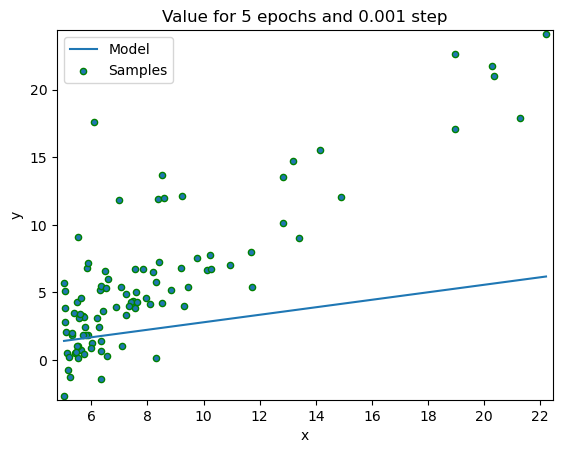

Final Loss Value: [17.003827337947612]


In [8]:
# Write the code to plot the line for the following cases:

# 5 Epochs
loss_values, theta = train_model(data, 5, 0.001)
plot_line(data, theta, 5, 0.001)
print(f"Final Loss Value: {loss_values[-1:]}")

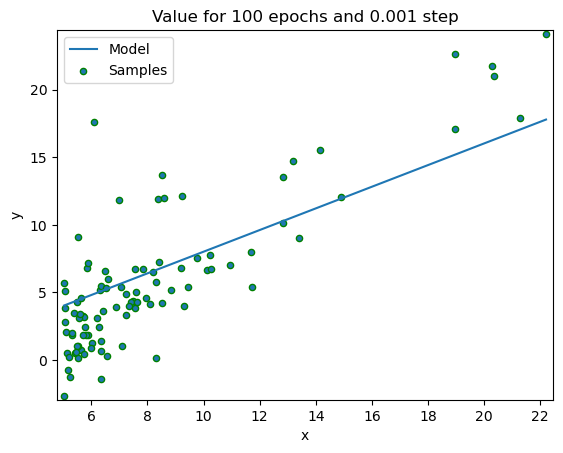

Final Loss Value: [5.864868428785698]


In [9]:
# 100 Epochs
loss_values, theta = train_model(data, 100, 0.001)
plot_line(data, theta, 100, 0.001)
print(f"Final Loss Value: {loss_values[-1:]}")

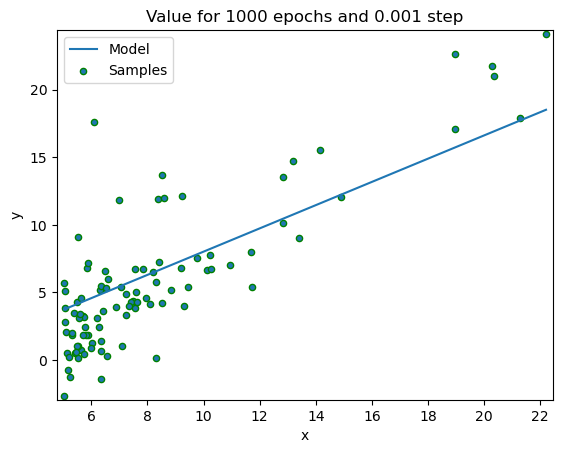

Final Loss Value: [5.480269332020323]


In [10]:
# 1000 Epochs
loss_values, theta = train_model(data, 1000, 0.001)
plot_line(data, theta, 1000, 0.001)
print(f"Final Loss Value: {loss_values[-1:]}")

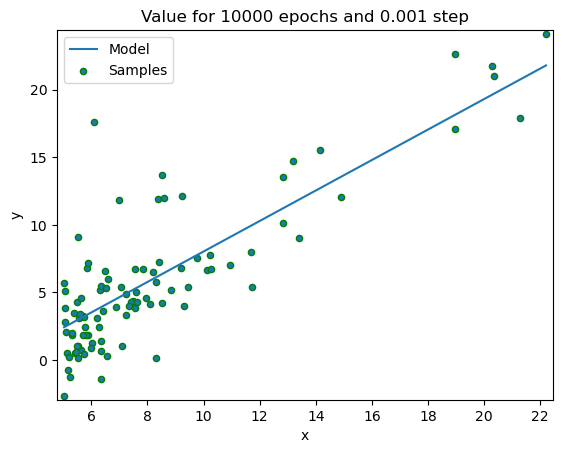

Final Loss Value: [4.516069827120197]


In [11]:
# 10,000 Epochs
loss_values, theta = train_model(data, 10000, 0.001)
plot_line(data, theta, 10000, 0.001)
print(f"Final Loss Value: {loss_values[-1:]}")

Using the results after 10,000 epochs, plot the loss values with respect to epochs using a line graph (epochs on the x axis and loss values on the y axis).

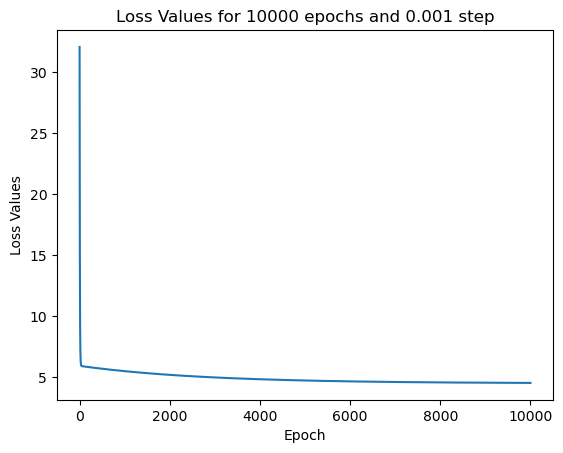

In [12]:
# Write the code to plot the loss values for each of the 10,000 iterations:
loss_values, theta = train_model(data, 10000, 0.001)
plt.plot(loss_values)
plt.title('Loss Values for 10000 epochs and 0.001 step')
plt.ylabel('Loss Values')
plt.xlabel('Epoch')
plt.show()

## Exercise 4: Discussion

Since learning a linear model is a convex optimization problem, you should see the model converge to a low mean squared error. However, you will need to tune the learning rate/step size, α (bear in mind that values that are too big will result in divergence).
Write a few sentences describing what you learned from the training/model fitting process. 

Things to discuss: What happens when you change the step size α? How many epochs did you need to converge on a reasonable solution (for any given step size)?

You should also discuss the hyperparameters you tried, and which ones worked best. 

In [13]:
import timeit

In [14]:
print("Time and Final Loss Value for epoch=1000 and step_size=0.001:\n")
loss_values, theta = train_model(data, 1000, 0.001)
%timeit loss_values, theta = train_model(data, 1000, 0.001)
# plot_line(data, theta, 1000, 0.001)
print(f"Final Loss Value: {loss_values[-1:]}")

Time and Final Loss Value for epoch=1000 and step_size=0.001:

32.7 ms ± 441 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
Final Loss Value: [5.480269332020323]


In [15]:
print("Time and Final Loss Value for epoch=1000 and step_size=0.0001:\n")
loss_values, theta = train_model(data, 1000, 0.0001)
%timeit loss_values, theta = train_model(data, 1000, 0.0001)
# plot_line(data, theta, 1000, 0.0001)
print(f"Final Loss Value: {loss_values[-1:]}")

Time and Final Loss Value for epoch=1000 and step_size=0.0001:

32.6 ms ± 296 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
Final Loss Value: [5.8648733284436645]


In [16]:
print("Time and Final Loss Value for epoch=10000 and step_size=0.001:\n")
loss_values, theta = train_model(data, 10000, .001)
%timeit loss_values, theta = train_model(data, 10000, .001)
# plot_line(data, theta, 10000, 0.001)
print(f"Final Loss Value: {loss_values[-1:]}")

Time and Final Loss Value for epoch=10000 and step_size=0.001:

202 ms ± 7.91 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Final Loss Value: [4.516069827120197]


In [17]:
print("Time and Final Loss Value for epoch=10000 and step_size=0.0001:\n")
loss_values, theta = train_model(data, 100000, 0.0001)
%timeit loss_values, theta = train_model(data, 10000, 0.0001)
# plot_line(data, theta, 10000, 0.0001)
print(f"Final Loss Value: {loss_values[-1:]}")

Time and Final Loss Value for epoch=10000 and step_size=0.0001:

196 ms ± 2.75 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
Final Loss Value: [4.516081264320027]


In [18]:
print("Time and Final Loss Value for epoch=100000 and step_size=0.001:\n")
loss_values, theta = train_model(data, 100000, 0.001)
%timeit loss_values, theta = train_model(data, 100000, 0.001)
# plot_line(data, theta, 100000, 0.001)
print(f"Final Loss Value: {loss_values[-1:]}")

Time and Final Loss Value for epoch=100000 and step_size=0.001:

1.86 s ± 3.05 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Final Loss Value: [4.476971375975179]


In [19]:
print("Time and Final Loss Value for epoch=100000 and step_size=0.0001:\n")
loss_values, theta = train_model(data, 100000, 0.0001)
%timeit loss_values, theta = train_model(data, 100000, 0.0001)
# plot_line(data, theta, 100000, 0.0001)
print(f"Final Loss Value: {loss_values[-1:]}")

Time and Final Loss Value for epoch=100000 and step_size=0.0001:

1.87 s ± 7.89 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Final Loss Value: [4.516081264320027]


> I observed that changing the step size affects how fast the model progresses, and also affects accuracy, though with diminishing returns.

> In some cases, when the the step size was too large, the model stepped too far, never converging to a least-squares loss.

> Once the step size was small enough for the loss function to converge, smaller step sizes allowed for greater accuracy, but with diminshing returns, and the amount of epochs would also have to be increased on the same magnitude.

> Increasing the epoch count increased runtime in the timed trials above. A sample comparison is listed here:

|# of Epochs|Step Size|Runtime   |Final Loss Value |
|-----------|---------|----------|-----------------|
|1000       |0.001    |32.7 ms   |5.480269332020323|
|1000       |0.0001   |32.6 ms   |5.864873328443664|
|10000      |0.001    |202 ms    |4.516069827120197|
|10000      |0.0001   |196 ms    |4.516081264320027|
|100000     |0.001    |1860 ms   |4.476971375975179|
|100000     |0.0001   |1870 ms   |4.516081264320027|

> Furthermore, the Final Loss Value for the model with a smallest step and corresponding largest epoch was practically the same as the one with larger step and smaller epoch (even having a greater loss value in this case).

|# of Epochs|Step Size|Runtime   |Final Loss Value |
|-----------|---------|----------|-----------------|
|10000      |0.001    |202 ms    |4.516069827120197|
|100000     |0.0001   |1870 ms   |4.516081264320027|

> In summary, increasing the number of epochs and decreasing the step size can improve convergence, but the gains may diminish while runtime increases.